# 02. Neural Network classification with PyTorch

Classification is a problem of predicting whether something is one thing or another (there can be multiple things as the options).

Book version of this notebook - https://www.learnpytorch.io/ All other resources - https://github.com/mrdbourke/pytorch-deep-learning 02 pytorch_classification/ uck? Ask a question - https://github.com/mrdbourke/pytorch-deep-learning/ discussions

In [ ]:
import sklearn
from sklearn.datasets import make_circles

In [ ]:
# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)


In [ ]:
print(f"First 5 samples of X:\n {X[:5]} ")
print(f"First 5 samples of y:\n {y[:5]}")

First 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]] 
First 5 samples of y:
 [1 1 1 1 0]


In [ ]:
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0],
                         "X2": X[:,1],
                         "labels": y})
circles.head()

,X1,X2,labels
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


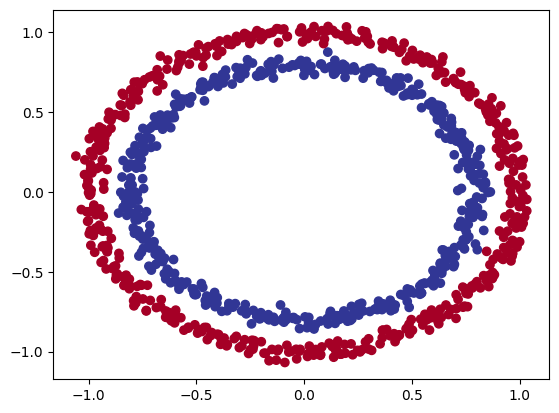

In [ ]:
# Visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu);

## 1.1 Chech input and output shapes

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


## 1.2 Turn data into tensors and crate train and test splits

In [ ]:
import torch
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
type(X), X.dtype


(torch.Tensor, torch.float32)

In [ ]:
# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model

Let's build a model to classify our blue and red dots.

To do so, we want to:

1. Setup device agonistic code so our code will run on an accelerator (GPU) if there is one

2. Construct a model (by subclassing `nn.Module` )

3. Define a loss function and optimizer

4. Create a training and test loop

In [ ]:
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Now we've setup device agnostic code, let's create a model that:
1. Subclasses `nn.Module `(almost all models in PyTorch subclass `nn.Module` )

2. Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data

3. Defines a `forward()` method that outlines the forward pass (or forward computation)

4. Instatiate an instance of our model class and send it to the target device

In [ ]:
# 1. Construct a model that subsclasses nn.Module
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)
    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) # x--> layer_1 --> layer_2 --> output

model = CircleModel().to(device)
model

CircleModel(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
1 # Make predictions
with torch.inference_mode():
  untrained_preds = model(X_test.to(device))
  print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
  print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
  print(f"\nFirst 10 predictions:\n{untrained_preds[ : 10] }" )
  print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667],
        [-0.1484],
        [-0.0826],
        [-0.0946],
        [-0.1918],
        [-0.0944]], device='cuda:0')

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Setup loss function and optimizer
Which loss function or optimizer should you use?

Again ... this is problem specific.

For example for regression you might want MAE or MSE (mean absolute error or mean squared error).

For classification you might want binary cross entropy or categorical cross entropy (cross entropy).

As a reminder, the loss function measures how *wrong* your models predictions are.

And for optimizers, two of the most common and useful are SGD and Adam, however PyTorch has many built-in options. options.

* For some common choices of loss functions and optimizers - https://www.learnpytorch.io/02_pytorch_classification/#21-setup-loss-function-and-optimizer

* For the loss function we're going to use `torch.nn.BECWithLogitsLoss()`, for more towardsdatascience.com/ on what binary cross entropy (BCE) is, check out this article - https://

* For a defintion on what a logit is in deep learning - https://stackoverflow.com/a/ standing-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a 52111173/7900723 For differer For different optimizers see `torch.optim`

In [ ]:
# Setup loss function
# loss_fn = nnBCELoss() = requires inputs to have gone through the sigmoid activation prior to input to BCELoss
loss_fn = nn.BCEWithLogitsLoss ()

optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)

In [ ]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

## 3. Train model

To train our model, we're going to need to build a training kiip with the following steps:

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**. We can convert these **logits** into **prediction probabilities** by passing them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our model's prediction probabilities to **prediction labels** by either rounding them or taking the `argmax()`

In [ ]:
# View the first 5 outputs of the forward pass on the test data
model.eval()
with torch.inference_mode():
  y_logits = model(X_test.to(device))[:5]
y_logits

tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667]], device='cuda:0')

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [ ]:
# Use the sigmoid activation function on our model logits to turn them into prediction probilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4683],
        [0.4758],
        [0.4524],
        [0.4728],
        [0.4584]], device='cuda:0')

In [ ]:
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')

# 3.2 Building a training and test loop

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
  model.train()

  # 1. Forward pass
  y_logits = model(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  # Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()


  model.eval()
  with torch.inference_mode():
    # 1. Forward passs
    test_logits = model(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate the test loss
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  if epoch % 10 == 0:
    print(f"Epoch:{epoch}  | Loss: {loss:.5f}, Acc: {acc:.2f}%  | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch:0  | Loss: 0.69569, Acc: 50.00%  | Test loss: 0.69721, Test acc: 50.00%
Epoch:10  | Loss: 0.69403, Acc: 50.00%  | Test loss: 0.69615, Test acc: 50.00%
Epoch:20  | Loss: 0.69343, Acc: 46.00%  | Test loss: 0.69585, Test acc: 48.50%
Epoch:30  | Loss: 0.69321, Acc: 49.00%  | Test loss: 0.69577, Test acc: 47.50%
Epoch:40  | Loss: 0.69312, Acc: 49.50%  | Test loss: 0.69573, Test acc: 46.50%
Epoch:50  | Loss: 0.69308, Acc: 50.38%  | Test loss: 0.69569, Test acc: 46.50%
Epoch:60  | Loss: 0.69306, Acc: 50.50%  | Test loss: 0.69564, Test acc: 46.50%
Epoch:70  | Loss: 0.69305, Acc: 50.50%  | Test loss: 0.69559, Test acc: 46.50%
Epoch:80  | Loss: 0.69304, Acc: 50.75%  | Test loss: 0.69553, Test acc: 46.50%
Epoch:90  | Loss: 0.69303, Acc: 50.38%  | Test loss: 0.69547, Test acc: 46.50%


In [ ]:
import requests
from pathlib import Path
# Download helper functions from Learn PyTorch repo (if it's not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  request = requests.get ("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  print("Downloading helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

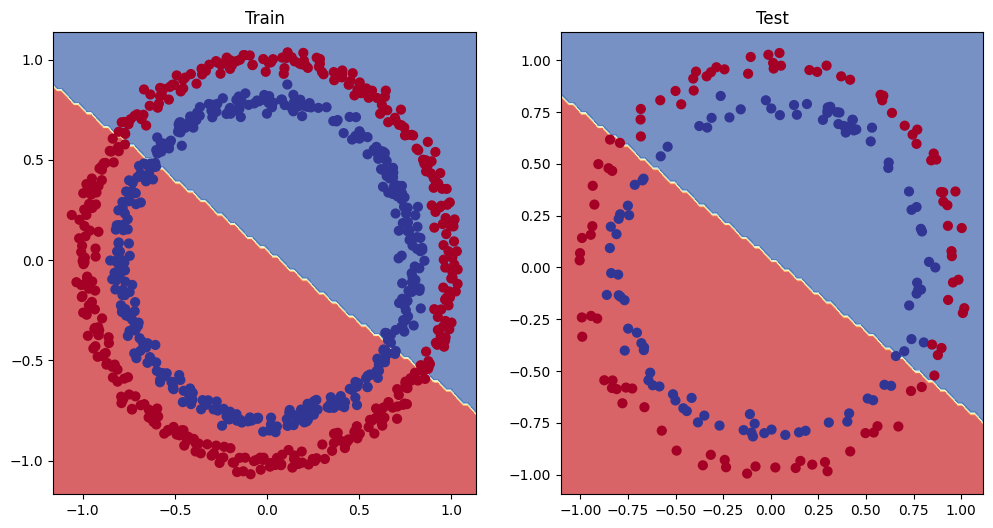

In [ ]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot (1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

## 5. Improving a model (from a model perspective)

* Add more layers - give the model more chances to learn about patterns in the data
* Add more hidden units - go from 5 hidden units to 10 hidden units
* Fit for longer
* Changing the activation functions
* Change the learning rate
* Change the loss function

In [ ]:
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2, out_features=10)
    self.layer2 = nn.Linear(in_features=10, out_features=10)
    self.layer3 = nn.Linear(in_features=10, out_features=1)

  def forward(self,x):
    return self.layer3(self.layer2(self.layer1(x)))

model2 = CircleModelV2().to(device)
model2

CircleModelV2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model2.parameters(),
                            lr=0.1)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
  model2.train()

  # 1. Forward pass
  y_logits = model2(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate the loss
  loss = loss_fn(y_logits,y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  #. 5. Optimizer step
  optimizer.step()

  model2.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model2(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate the test loss
    test_loss = loss_fn(test_logits, y_test)
    acc = accuracy_fn(y_pred=test_preds, y_true=y_test)

  if epoch % 100 == 0:
    print(f"Epoch:{epoch}  | Loss: {loss:.5f}, Acc: {acc:.2f}%  | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch:0  | Loss: 0.69396, Acc: 51.00%  | Test loss: 0.69261, Test acc: 46.50%
Epoch:100  | Loss: 0.69305, Acc: 48.00%  | Test loss: 0.69379, Test acc: 46.50%
Epoch:200  | Loss: 0.69299, Acc: 46.00%  | Test loss: 0.69437, Test acc: 46.50%
Epoch:300  | Loss: 0.69298, Acc: 45.00%  | Test loss: 0.69458, Test acc: 46.50%
Epoch:400  | Loss: 0.69298, Acc: 46.00%  | Test loss: 0.69465, Test acc: 46.50%
Epoch:500  | Loss: 0.69298, Acc: 46.00%  | Test loss: 0.69467, Test acc: 46.50%
Epoch:600  | Loss: 0.69298, Acc: 46.00%  | Test loss: 0.69468, Test acc: 46.50%
Epoch:700  | Loss: 0.69298, Acc: 46.00%  | Test loss: 0.69468, Test acc: 46.50%
Epoch:800  | Loss: 0.69298, Acc: 46.00%  | Test loss: 0.69468, Test acc: 46.50%
Epoch:900  | Loss: 0.69298, Acc: 46.00%  | Test loss: 0.69468, Test acc: 46.50%


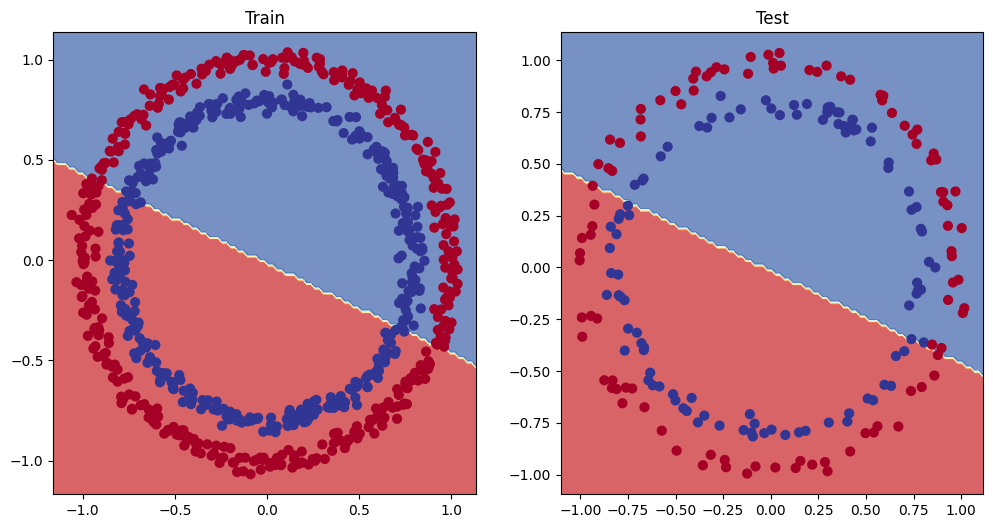

In [ ]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot (1, 2, 1)
plt.title("Train")
plot_decision_boundary(model2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model2, X_test, y_test)

In [ ]:
# Create some data which is fits that model
weight = 0.7
bias = 0.3
start=0
end=1
step=0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # Linear regression formula (without epsilon)

In [ ]:
torch.manual_seed(42)
train_split = int(0.8*len(X_regression))
X_train_regression, y_train_regression = X_regression[ : train_split], y_regression[ :train_split]
X_test_regression, y_test_regression = X_regression[train_split: ], y_regression[train_split: ]

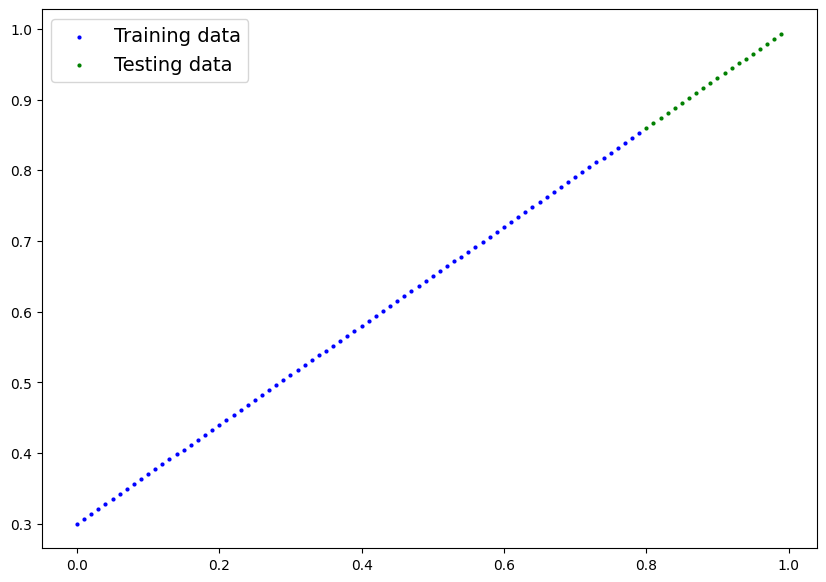

In [ ]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression)

In [ ]:
model3 = nn.Sequential(
   nn.Linear(in_features=1, out_features=10),
   nn.Linear(in_features=10, out_features=10),
   nn.Linear(in_features=10, out_features=1)
).to(device)

model3

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model3.parameters(),
                            lr=0.001)


In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs= 1000

X_train_regression, X_test_regression = X_train_regression.to(device), X_test_regression.to(device)
y_train_regression, y_test_regression = y_train_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
  model3.train()

  y_pred=model3(X_train_regression)

  loss = loss_fn(y_train_regression, y_pred)
  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model3.eval()
  with torch.inference_mode():

    test_pred = model3(X_test_regression)

    test_loss = loss_fn(test_pred, y_test_regression)
  if epoch % 100 == 0:
    print(f"Epoch:{epoch}  | Loss: {loss:.5f}  | Test loss: {test_loss:.5f}")

Epoch:0  | Loss: 0.75986  | Test loss: 0.94965
Epoch:100  | Loss: 0.40272  | Test loss: 0.54029
Epoch:200  | Loss: 0.05876  | Test loss: 0.13480
Epoch:300  | Loss: 0.01461  | Test loss: 0.03342
Epoch:400  | Loss: 0.00308  | Test loss: 0.00008
Epoch:500  | Loss: 0.00309  | Test loss: 0.00012
Epoch:600  | Loss: 0.00309  | Test loss: 0.00018
Epoch:700  | Loss: 0.00299  | Test loss: 0.00011
Epoch:800  | Loss: 0.00299  | Test loss: 0.00016
Epoch:900  | Loss: 0.00289  | Test loss: 0.00011


## 6. The missing piece: non-linearity

"What patterns could you draw if you were given an infinite amount of a straight and non-straight lines?"

Or in machine learning terms, an infinite (but really it is finite) of linear and non-linear functions?

## Recreating non-linear data

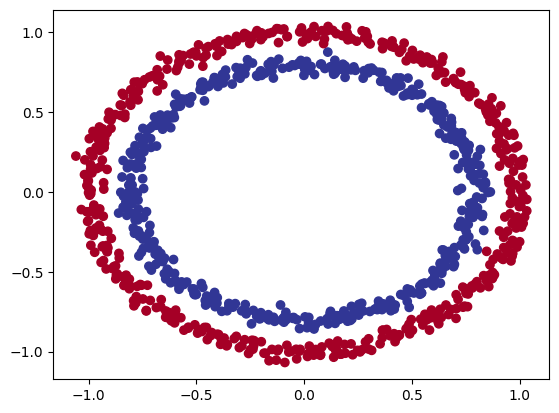

In [ ]:
# Make data and plot
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu);

In [ ]:
# Convert data to tensors
import torch
from sklearn.model_selection import train_test_split

X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from torch import nn
class CircleModelV3(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2, out_features=10)
    self.layer2 = nn.Linear(in_features=10, out_features=10)
    self.layer3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()
  def forward(self,x):
     return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model3 = CircleModelV3().to(device)
model3

CircleModelV3(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

In [ ]:
# Setup loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model3.parameters(),lr=0.01)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
  model3.train()

  train_logits = model3(X_train).squeeze()
  train_preds = torch.round(torch.sigmoid(train_logits))

  loss = loss_fn(train_logits, y_train)
  acc = accuracy_fn(y_train, train_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model3.eval()
  with torch.inference_mode():
    test_logits = model3(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_preds,y_test)
    test_acc = accuracy_fn(y_test, test_preds)
  if epoch % 100 == 0:
    print(f"Epoch:{epoch}  | Loss: {loss:.5f}  Acc: {acc:.2f}%  | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

Epoch:0  | Loss: 0.69295  Acc: 50.00%  | Test loss: 0.81326 | Test acc: 50.00%
Epoch:100  | Loss: 0.69248  Acc: 50.38%  | Test loss: 0.81326 | Test acc: 50.00%
Epoch:200  | Loss: 0.69225  Acc: 59.00%  | Test loss: 0.77245 | Test acc: 56.00%
Epoch:300  | Loss: 0.69209  Acc: 70.12%  | Test loss: 0.69343 | Test acc: 67.00%
Epoch:400  | Loss: 0.69195  Acc: 68.38%  | Test loss: 0.65921 | Test acc: 70.00%
Epoch:500  | Loss: 0.69181  Acc: 58.50%  | Test loss: 0.67879 | Test acc: 62.00%
Epoch:600  | Loss: 0.69168  Acc: 54.00%  | Test loss: 0.69798 | Test acc: 56.00%
Epoch:700  | Loss: 0.69155  Acc: 53.25%  | Test loss: 0.70938 | Test acc: 53.00%
Epoch:800  | Loss: 0.69141  Acc: 52.62%  | Test loss: 0.70938 | Test acc: 53.00%
Epoch:900  | Loss: 0.69128  Acc: 52.75%  | Test loss: 0.70938 | Test acc: 53.00%


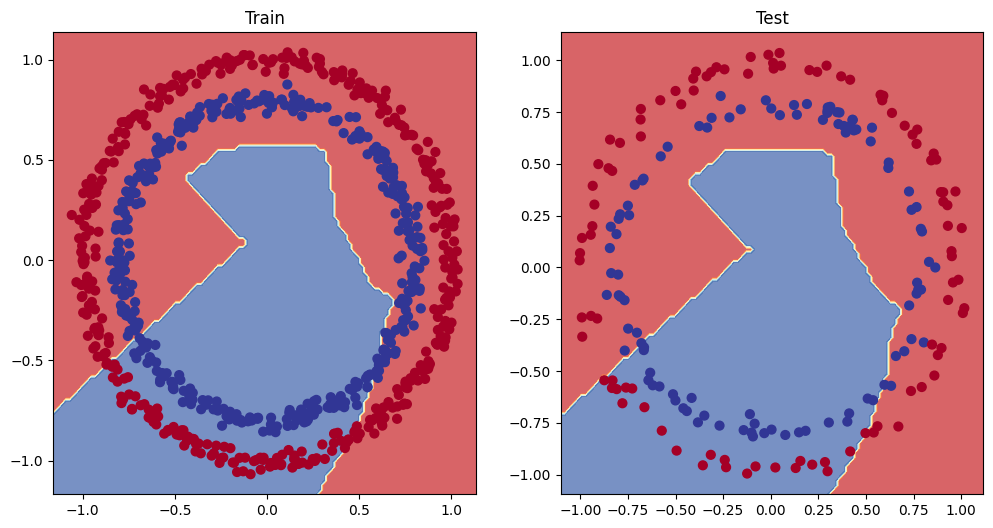

In [ ]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot (1, 2, 1)
plt.title("Train")
plot_decision_boundary(model3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model3, X_test, y_test)

In [ ]:
A = torch.arange(-10,10,0.1)

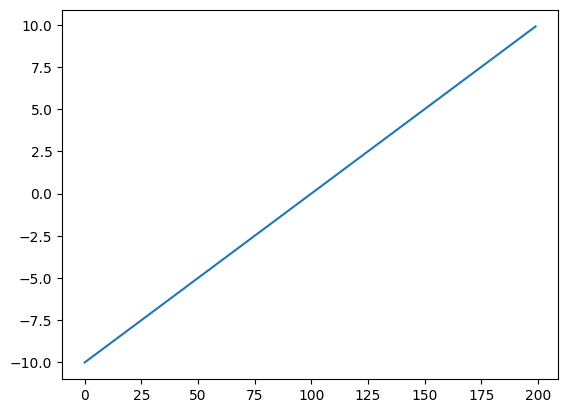

In [ ]:
plt.plot(A)

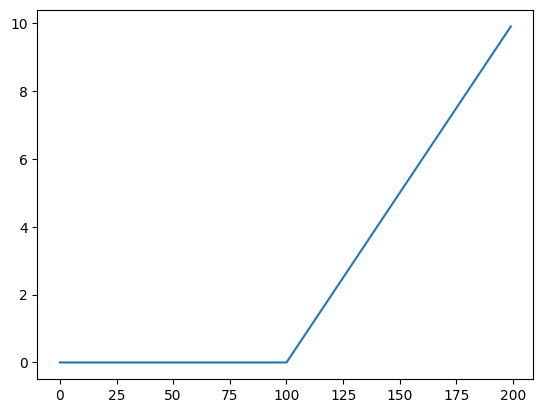

In [ ]:
# fonksiyonlarun arkasindaki matematik

def relu(x):
  return torch.max(torch.tensor(0), x)

plt.plot(relu(A))

In [ ]:
# fonksiyonlarin arkasindaki matematik

def sigmoid(x):
  return 1 / (1 + torch.exp(-x))


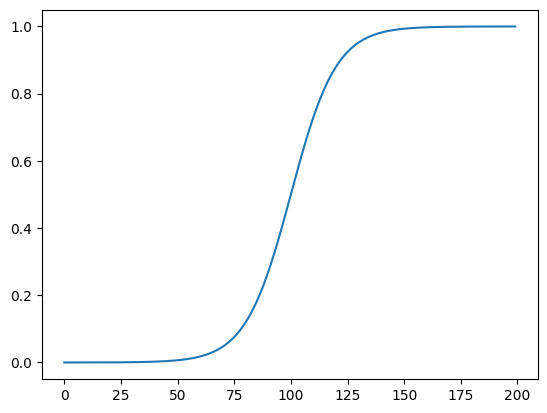

In [ ]:
plt.plot(sigmoid(A))

##8. Putting it all together with a multi-class classification problem

* Binary classification = one thing or another (cat vs. dog, spam vs. not spam, fraud or not fraud)

* Multi-class classification = more than one thing or another (cat vs. dog vs. chicken)

### 8.1 Creating a toy multi-class dataset

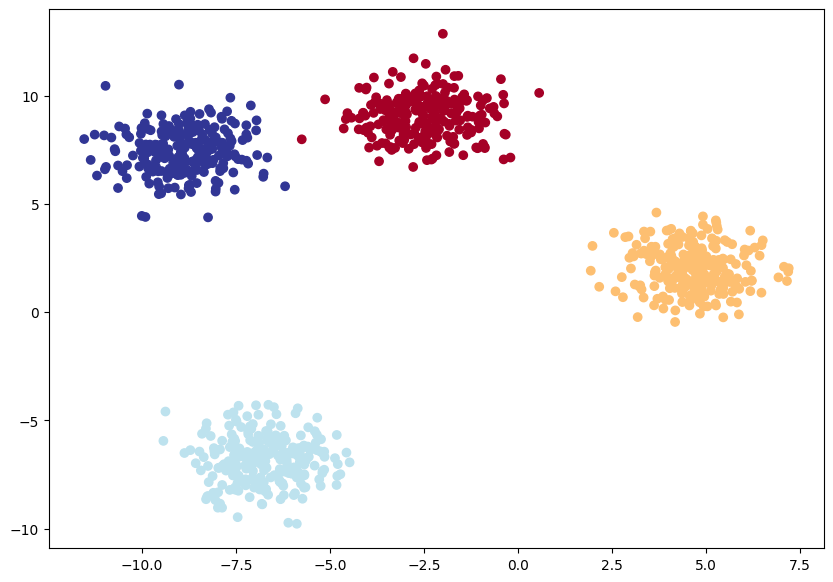

In [ ]:
# Import dependiences
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from torch import nn

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1.Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            random_state=RANDOM_SEED)
# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Split the data
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size=0.2)

# 4. Plot data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:, 0], X_blob[:,1], c=y_blob, cmap=plt.cm.RdYlBu);

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):

    """Initializes multi-class classification model.

    Args:
      input_features (int): Number of input features to the model
      output_features (int): Number of outputs features (number of output classes)
      hidden_units (int): Number of hidden units between layers, default 8

    Returns:

    Example:
    """
    super().__init__()
    self.linerar_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features),
    )

  def forward(self,x):
    return self.linerar_layer_stack(x)

model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)

In [ ]:
# Create a loss function
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1)

In [ ]:
X_blob_train, X_blob_test = X_blob_train.to(device), X_blob_test.to(device)
y_blob_train, y_blob_test = y_blob_train.to(device), y_blob_test.to(device)

In [ ]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test.to(device))

y_logits[:10]

tensor([[-0.6872, -0.6438, -1.3645, -0.9665],
        [-0.8042, -0.7445, -1.6321, -1.1825],
        [-0.2633, -1.2836, -1.0448, -0.3098],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.5531, -0.5888, -1.1725, -0.8845],
        [-0.6313, -0.6477, -1.3258, -0.9928],
        [-0.1357, -1.0113, -0.7265, -0.2033],
        [-0.1294, -1.0130, -0.6731, -0.1606],
        [-0.1314, -1.0172, -0.6785, -0.1626],
        [ 0.2528, -0.2379,  0.1882, -0.0066]], device='cuda:0')

In [ ]:
# Convert out model's logit outputs to prediction probabilities
y_pred_prob = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_prob[:5])

tensor([[-0.6872, -0.6438, -1.3645, -0.9665],
        [-0.8042, -0.7445, -1.6321, -1.1825],
        [-0.2633, -1.2836, -1.0448, -0.3098],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.5531, -0.5888, -1.1725, -0.8845]], device='cuda:0')
tensor([[0.3022, 0.3156, 0.1535, 0.2286],
        [0.3141, 0.3334, 0.1373, 0.2152],
        [0.3606, 0.1300, 0.1651, 0.3443],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3105, 0.2996, 0.1671, 0.2229]], device='cuda:0')


In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

for epoch in range(epochs):
  model_4.train()

  y_logits = model_4(X_blob_train).squeeze()
  y_train_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_blob_train)
  acc = accuracy_fn(y_blob_train, y_train_preds)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_fn(y_blob_test, test_preds)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss :.4f}, Acc: {acc :.2f}% | Test loss: {test_loss :.4f}, Test acc: {test_acc :.2f}%")


Epoch: 0 | Loss: 1.1507, Acc: 38.25% | Test loss: 1.0622, Test acc: 50.50%
Epoch: 10 | Loss: 0.6280, Acc: 98.62% | Test loss: 0.6089, Test acc: 98.50%
Epoch: 20 | Loss: 0.3847, Acc: 99.88% | Test loss: 0.3800, Test acc: 99.50%
Epoch: 30 | Loss: 0.2012, Acc: 100.00% | Test loss: 0.1986, Test acc: 99.50%
Epoch: 40 | Loss: 0.0699, Acc: 100.00% | Test loss: 0.0695, Test acc: 99.50%
Epoch: 50 | Loss: 0.0328, Acc: 100.00% | Test loss: 0.0366, Test acc: 99.50%
Epoch: 60 | Loss: 0.0209, Acc: 100.00% | Test loss: 0.0260, Test acc: 99.50%
Epoch: 70 | Loss: 0.0152, Acc: 100.00% | Test loss: 0.0207, Test acc: 99.50%
Epoch: 80 | Loss: 0.0119, Acc: 100.00% | Test loss: 0.0176, Test acc: 99.50%
Epoch: 90 | Loss: 0.0097, Acc: 100.00% | Test loss: 0.0156, Test acc: 99.50%


In [ ]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test.to(device))

y_pred_prob = torch.softmax(y_logits, dim=1).argmax(dim=1)
print(y_blob_test[:15])
print(y_pred_prob[:15])

tensor([1, 1, 0, 2, 1, 1, 0, 3, 3, 2, 3, 0, 1, 2, 2], device='cuda:0')
tensor([1, 1, 0, 2, 1, 1, 0, 3, 3, 2, 3, 0, 1, 2, 2], device='cuda:0')


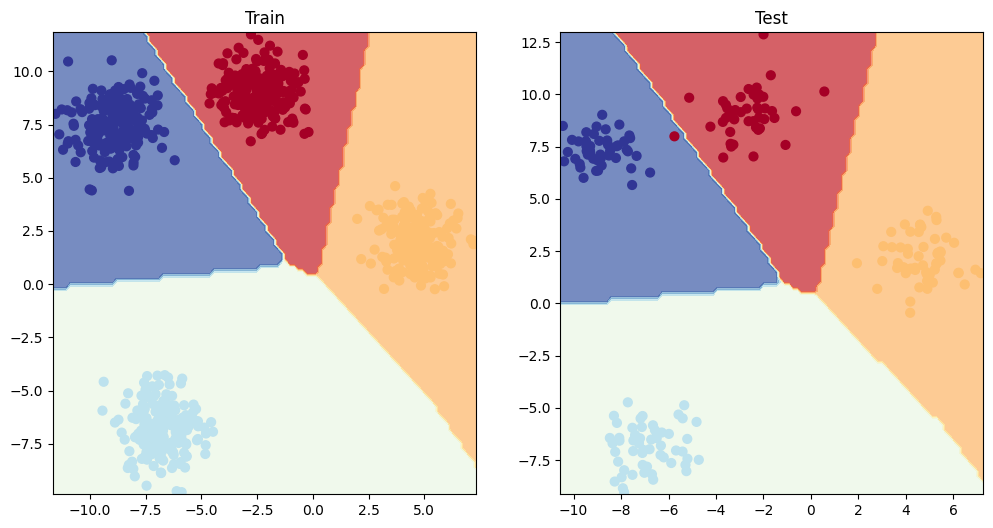

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)